In [1]:
import lzma 
import dill as pickle

from matplotlib import pyplot as plt
import numpy as np

In [2]:
with lzma.open("./data/diff_xs_observations.lz", "rb") as f:
    diff_xs_obs = pickle.load(f)

Using database version X4-2025-12-31 located in: /mnt/home/beyerkyl/x4db/unpack_exfor-2025/X4-2025-12-31


/tmp/mpl-usetex-beyerkyl/ipykernel_3804855/2898546485.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig = plt.figure()


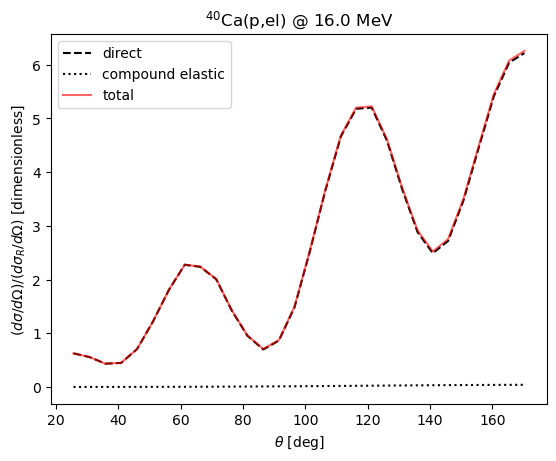

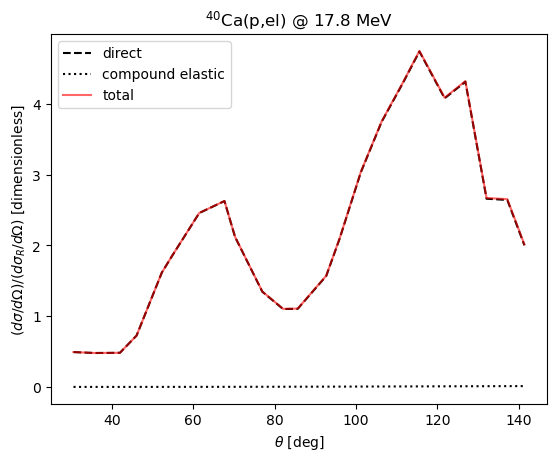

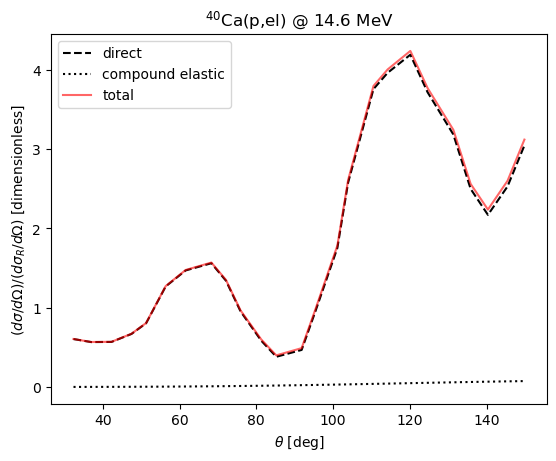

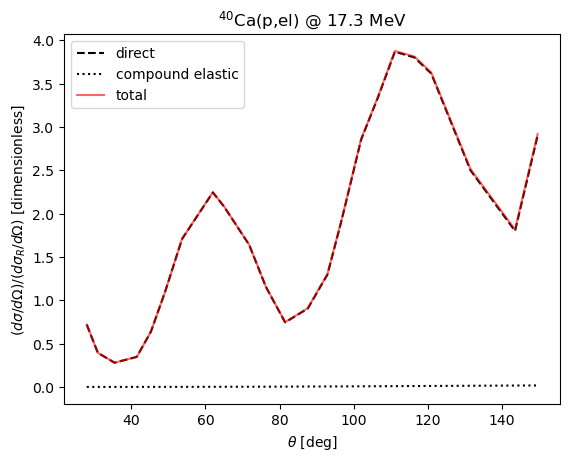

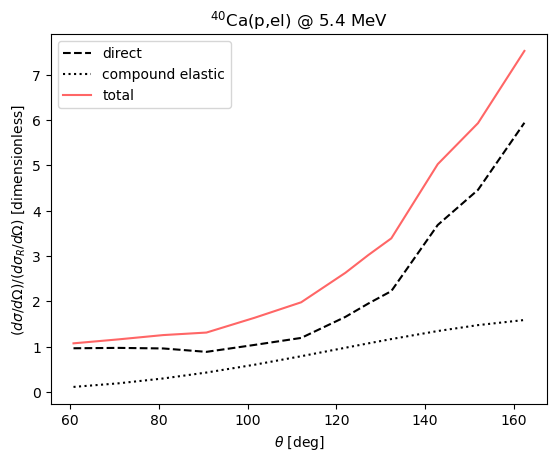

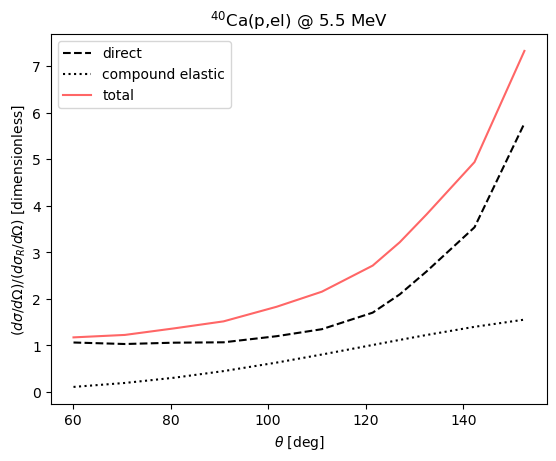

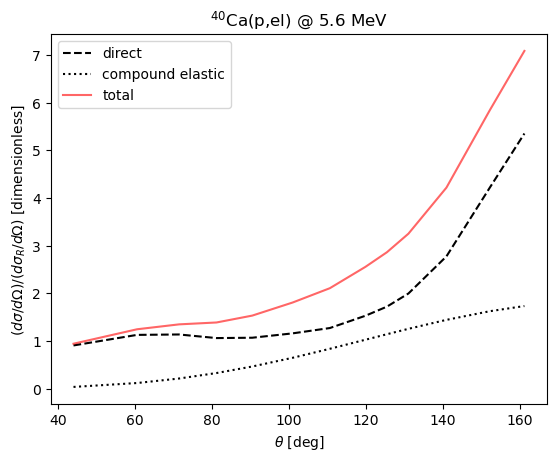

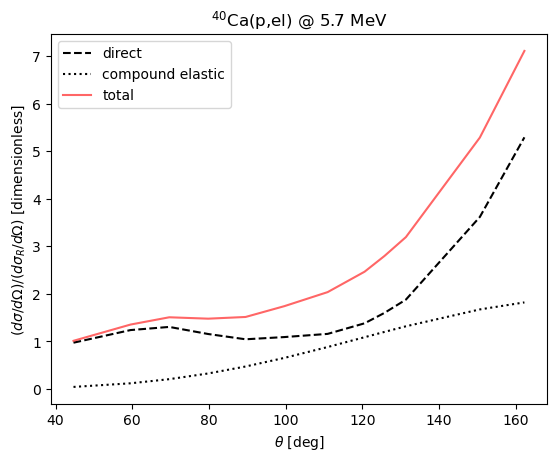

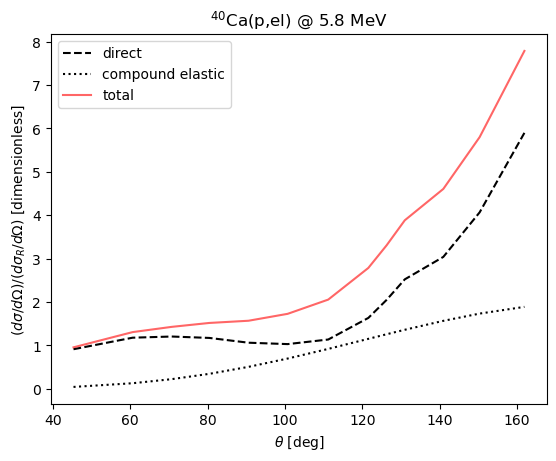

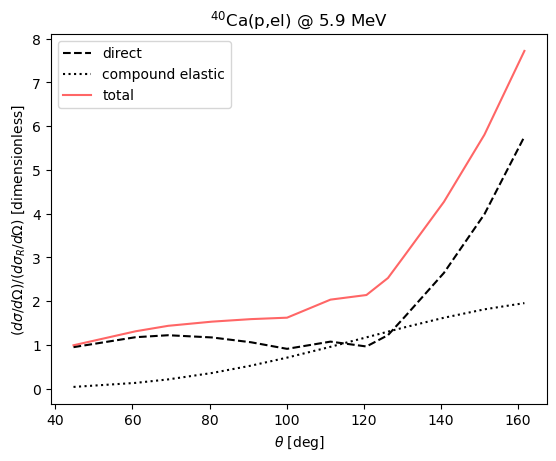

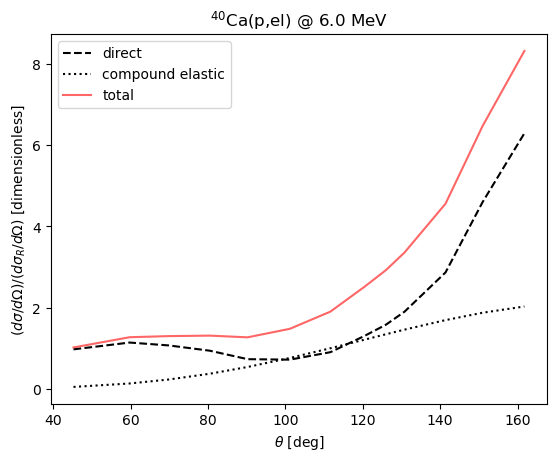

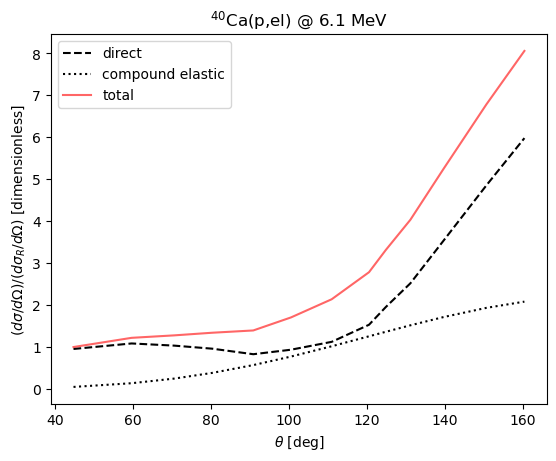

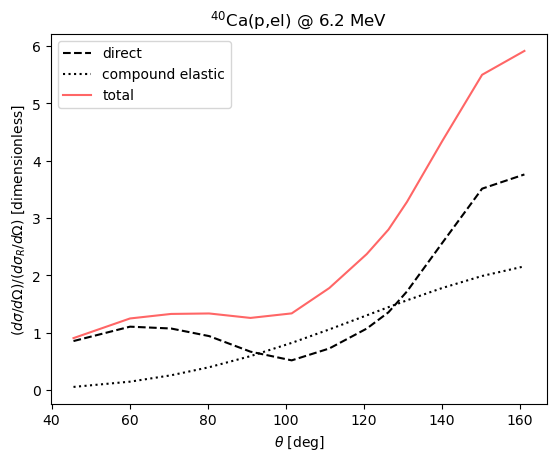

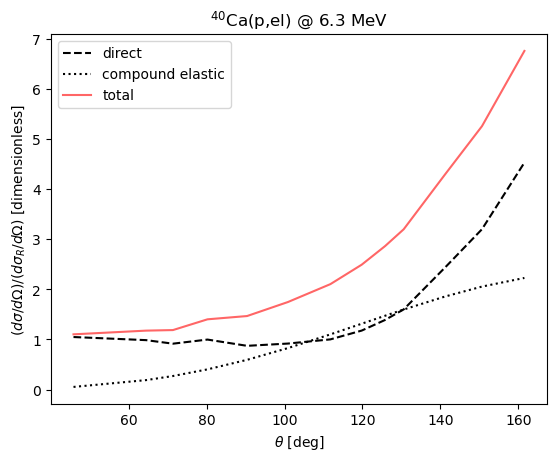

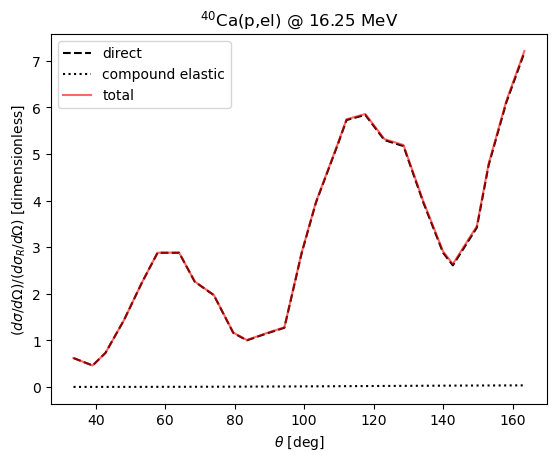

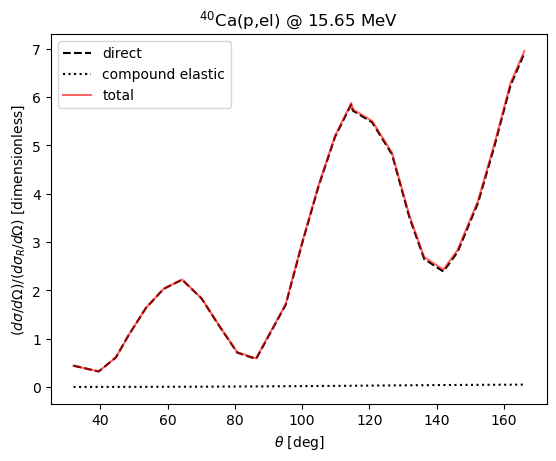

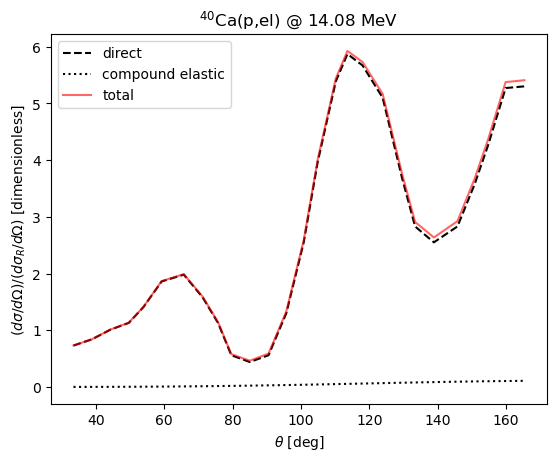

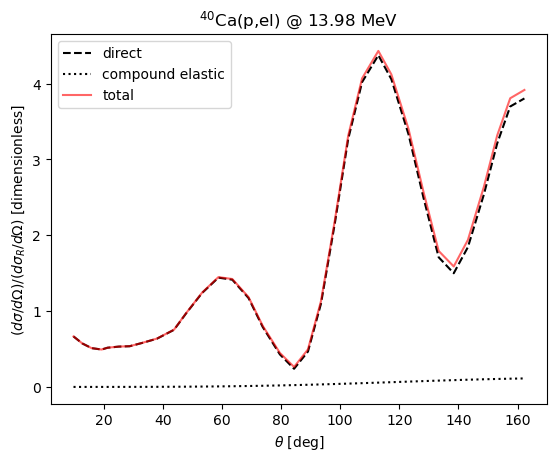

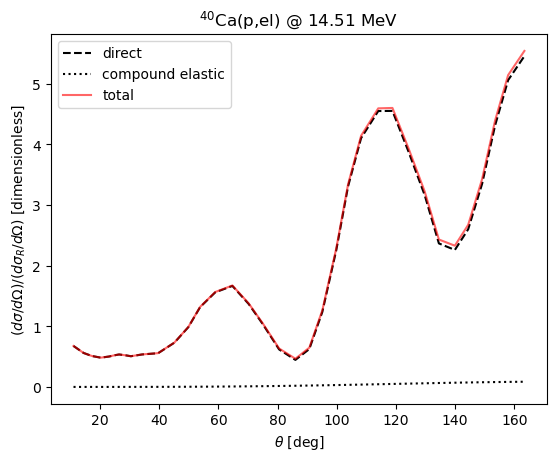

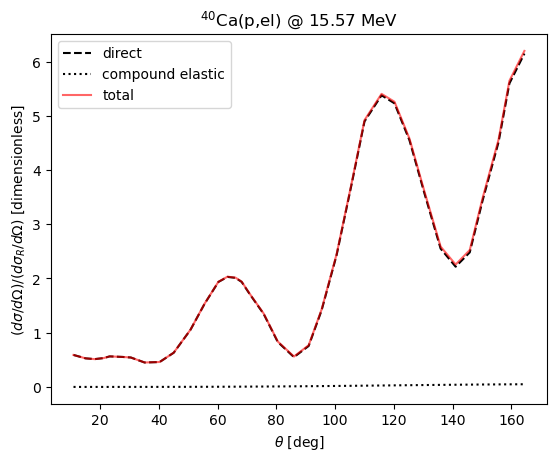

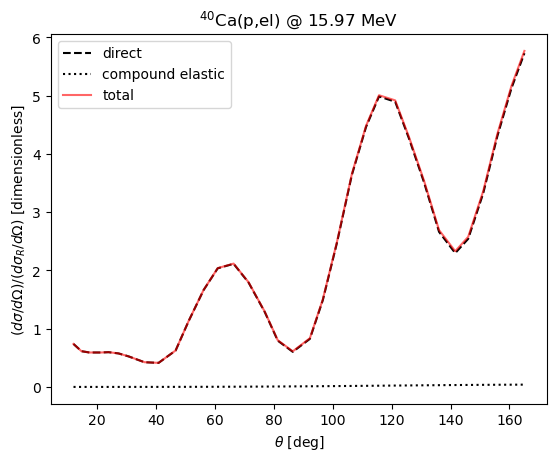

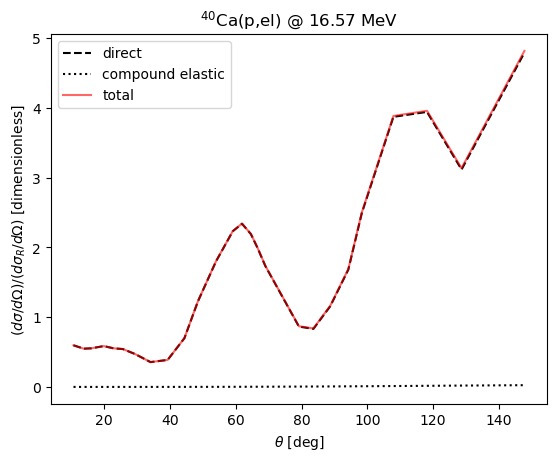

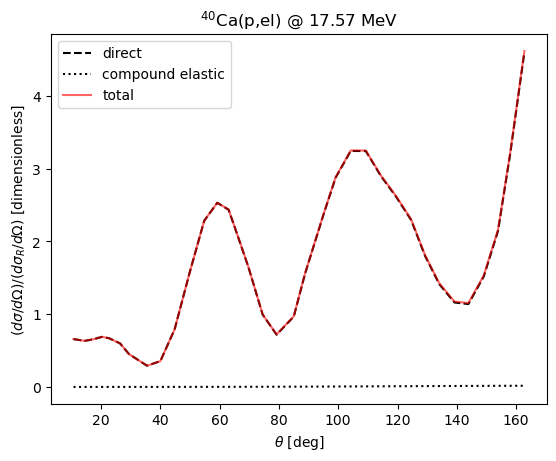

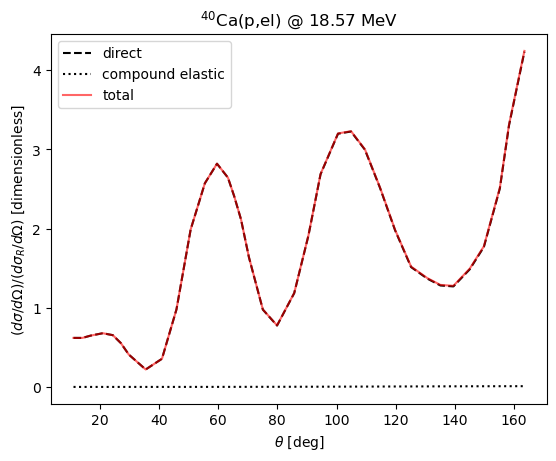

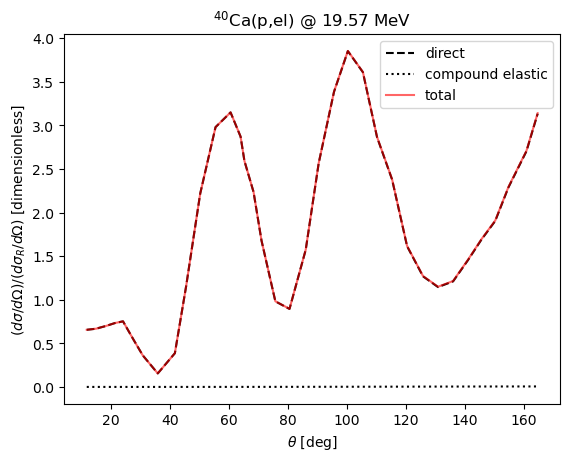

In [10]:
for obs in diff_xs_obs:
    if obs.compound_correction is not None:

        fig = plt.figure()
        x = np.rad2deg(obs.x)
        y = obs.y
        plt.plot(x,y, "--k", label="direct")

        cn = obs.compound_correction / obs.constraint_workspace.rutherford
        plt.plot(x,cn, "k:", label="compound elastic")

        plt.plot(x, y + cn, "r", label="total",alpha=0.6)
        plt.legend()
        plt.xlabel(r"$\theta$ [deg]")
        plt.ylabel(r"$(d\sigma/d\Omega) / (d\sigma_{R}/d\Omega)$ [dimensionless]")
    
        plt.title(f"$^{{{40}}}$Ca(p,el) @ {obs.constraint_workspace.kinematics.Elab} MeV")